# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 04: Regressão**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_04_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>R. Quinlan. "Auto MPG," UCI Machine Learning Repository, 1993.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5859H</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/9/auto+mpg</font>

## <font color='green'>Preparação</font>

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

In [9]:
from ucimlrepo import fetch_ucirepo

# Importar o dataset Auto MPG (ID 9)
auto_mpg = fetch_ucirepo(id=9)

# Extrair as variáveis independentes (X) e a variável alvo (y)
X = auto_mpg.data.features
y = auto_mpg.data.targets

# Ver as primeiras linhas
display(X.head())

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1


## <font color='green'>**1. Análise Exploratória de Dados (EDA)**</font>

### <font color='cyan'>Q1) Verifique se há amostras com valores ausentes no conjunto de dados. Se houver, remova-as e informe quantas foram removidas.</font>

In [10]:
print(X.isnull().sum())

linhas_antes = X.shape[0]

dados = X.copy()
dados["mpg"] = y

dados_limpos = dados.dropna()

linhas_depois = dados_limpos.shape[0]

removidas = linhas_antes - linhas_depois

print(f"\nQuantidade de amostras removidas: {removidas}")

# Atualizar X e y sem valores ausentes
X = dados_limpos.drop(columns=["mpg"])
y = dados_limpos["mpg"]

displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

Quantidade de amostras removidas: 6


### <font color='cyan'>Q2) Plote um histograma da coluna alvo `y` (MPG) utilizando `matplotlib` ou `seaborn`. Adicione título e rótulos aos eixos.</font>

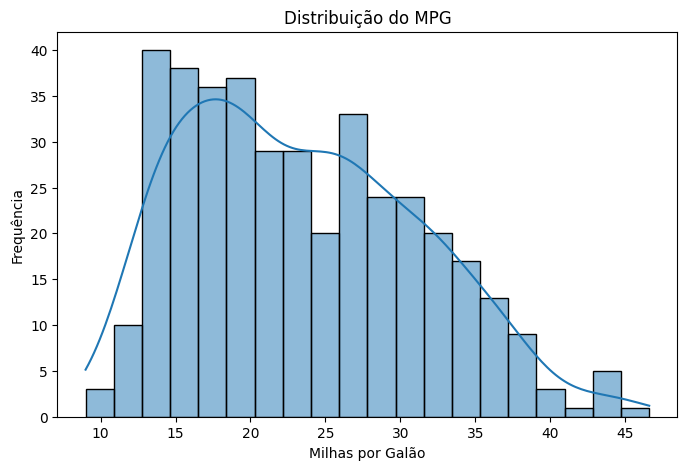

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(y, bins=20, kde=True)

plt.title("Distribuição do MPG")
plt.xlabel("Milhas por Galão")
plt.ylabel("Frequência")
plt.show()

### <font color='cyan'>Q3) O que a distribuição do histograma nos diz sobre o consumo de combustível da maioria dos carros desse dataset?</font>

Mostra que a maior parte dos carros do dataset possui valores de MPG entre 15 e 30 MPG. Indica que a maioria dos veículos não é extremamente econômicos nem muito ineficientes.

## <font color='green'>**2. Regressão Linear, Polinomial e Visualização**</font>

### <font color='cyan'>Q4) Crie um gráfico de dispersão (scatter plot) de `weight` vs `mpg`.</font>

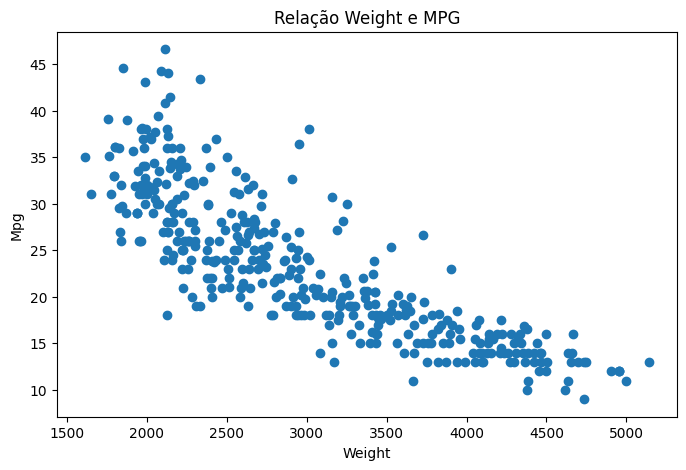

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(X["weight"], y)

plt.title("Relação Weight e MPG")
plt.xlabel("Weight")
plt.ylabel("Mpg")
plt.show()

### <font color='cyan'>Q5) Observando o gráfico de dispersão gerado na questão anterior, como você descreveria a relação entre o peso do veículo (weight) e o consumo de combustível (mpg)? A relação parece ser estritamente linear ou apresenta um comportamento não linear? Justifique sua resposta.</font>

Os veículos mais pesados consomem mais combustível, existe uma relação inversa entre o weight e o mpg. Aparenta ser não linear.

### <font color='cyan'>Q6) Divida o conjunto de dados em treinamento (80%) e teste (20%), utilizando a variável `weight` como entrada e `mpg` como alvo, e em seguida construa um gráfico de dispersão que apresente os dois subconjuntos com cores diferentes, incluindo título, rótulos dos eixos e uma legenda para identificar claramente os dados de treino e de teste.</font>

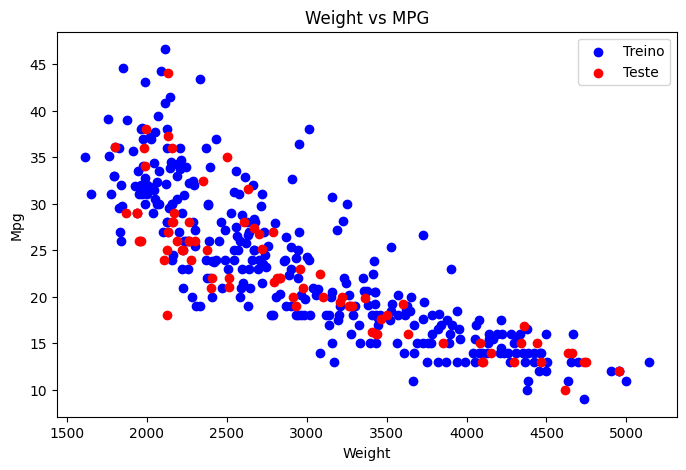

In [17]:
from sklearn.model_selection import train_test_split


X_weight = X[["weight"]]
y_mpg = y


X_train, X_test, y_train, y_test = train_test_split(
    X_weight,
    y_mpg,
    test_size=0.2,
    random_state=42
)
plt.figure(figsize=(8,5))


plt.scatter(
    X_train,
    y_train,
    color="blue",
    label="Treino"
)

plt.scatter(
    X_test,
    y_test,
    color="red",
    label="Teste"
)


plt.title("Weight vs MPG")
plt.xlabel("Weight")
plt.ylabel("Mpg")
plt.legend()
plt.show()

### <font color='cyan'>Q7) Com base na distribuição dos pontos no gráfico gerado, os conjuntos de treinamento e teste parecem ser representativos do conjunto de dados original? Justifique sua resposta observando a dispersão das cores.</font>

Sim, os conjuntos de treinamento e teste parecem ser representativos do conjunto de dados original. Pois não há concentração dos dados de teste em apenas uma região específica do gráfico, o que indica que a divisão foi equilibrada

### <font color='green'>Antes de avaliarmos nosso modelo, vamos entender brevemente o que cada métrica significa e quais funções da biblioteca [`sklearn.metrics`](https://scikit-learn.org/stable/api/sklearn.metrics.html) utilizaremos:</font>
- #### <font color='green'>R² (Coeficiente de Determinação) - função `r2_score(y_true, y_pred)`: Mede o quão bem o modelo se ajusta aos dados. Ele indica a proporção da variabilidade da variável alvo (MPG) que é explicada pelo modelo. Varia geralmente de 0 a 1 (podendo ser negativo se o modelo for pior que uma linha média). Quanto mais próximo de 1, melhor.</font>
- #### <font color='green'>MAE (Erro Absoluto Médio - Mean Absolute Error) - função `mean_absolute_error(y_true, y_pred)`: Representa a média das diferenças em valor absoluto entre as previsões do modelo e os valores reais. É uma métrica muito intuitiva porque o erro é retornado na mesma unidade da variável alvo (ou seja, errar por "3 MPG"). Quanto menor, melhor.</font>
- #### <font color='green'>MSE (Erro Quadrático Médio - Mean Squared Error) - função `mean_squared_error(y_true, y_pred)`: Calcula a média dos erros elevados ao quadrado. Como os erros são elevados ao quadrado, o MSE penaliza erros maiores (outliers) de forma mais severa do que o MAE. Quanto menor, melhor.</font>

### <font color='cyan'>Q8) Importe as funções `r2_score`, `mean_absolute_error` e `mean_squared_error` do módulo `sklearn.metrics`. Em seguida, treine um modelo de Regressão Linear Simples para prever o MPG usando o peso. Faça as previsões para o conjunto de treinamento e para o conjunto de teste. Por fim, imprima as métricas (R², MAE e MSE) para ambos os conjuntos.</font>

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


modelo_linear = LinearRegression()


modelo_linear.fit(X_train, y_train)


y_train_pred = modelo_linear.predict(X_train)
y_test_pred = modelo_linear.predict(X_test)


print("TREINAMENTO:")
print("R²:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("MSE:", mean_squared_error(y_train, y_train_pred))


print("TESTE:")
print("R²:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))

TREINAMENTO:
R²: 0.6981745885310532
MAE: 3.2855106233763385
MSE: 19.04510619658238
TESTE:
R²: 0.6533466675646016
MAE: 3.4641211922147592
MSE: 17.693388269545686


### <font color='cyan'>Q9) Compare os erros (MAE e MSE) obtidos no conjunto de treinamento com os erros do conjunto de teste. Com base nessa comparação e no conceito de viés/variância, o modelo parece estar sofrendo de subajuste (underfitting), sobreajuste (overfitting) ou apresenta um bom ajuste? Justifique.</font>

Underfitting pois a relação entre weight e mpg é não linear, o modelo pode não capturar totalmente o comportamento dos dados e mesmo assim, ele ainda consegue representar bem a tendência geral entre as variáveis.

### <font color='cyan'>Q10) Treine um modelo de Regressão Polinomial (grau 2) para prever o MPG usando o peso. em seguida, Assim como na questão anterior, faça previsões e imprima as métricas (R², MAE e MSE) para os conjuntos de treinamento e de teste.</font>
- #### <font color='cyan'>Dica: Como as características polinomiais elevam os valores ao quadrado, a escala dos dados muda drasticamente. Utilize a classe `Pipeline` do Scikit-Learn para encadear a criação de `PolynomialFeatures(degree=2)`, a normalização com StandardScaler e o modelo LinearRegression.<font>

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler


modelo_polinomial = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])


modelo_polinomial.fit(X_train, y_train)
y_train_poly = modelo_polinomial.predict(X_train)
y_test_poly = modelo_polinomial.predict(X_test)


print("TREINAMENTO:")
print("R²:", r2_score(y_train, y_train_poly))
print("MAE:", mean_absolute_error(y_train, y_train_poly))
print("MSE:", mean_squared_error(y_train, y_train_poly))


print("TESTE:")
print("R²:", r2_score(y_test, y_test_poly))
print("MAE:", mean_absolute_error(y_test, y_test_poly))
print("MSE:", mean_squared_error(y_test, y_test_poly))

TREINAMENTO:
R²: 0.72134647941912
MAE: 3.079780589881891
MSE: 17.582965813534294
TESTE:
R²: 0.6730234425893193
MAE: 3.1383262829057914
MSE: 16.689074196004476


### <font color='cyan'>Q11) Avaliando os erros de treinamento e teste deste modelo polinomial (grau 2), como ele se compara ao modelo linear da questão anterior? Ele apresenta sinais de underfitting, overfitting ou um bom ajuste aos dados? Justifique.</font>

Ele apresenta melhores métricas do que o modelo linear, com valores de R² maiores e erros MAE e MSE menores. Isso acontece porque ele consegue representar melhor a leve curvatura existente na relação entre weight e mpg. Como os erros de treinamento e teste permanecem próximos, o modelo não apresenta sinais fortes de overfitting. Portanto, ele demonstra um ajuste melhor aos dados do que a regressão linear simples.

### <font color='cyan'>Q12) Utilizando os modelos já treinados, construa um gráfico de dispersão com os dados reais de treinamento e teste (`weight` vs `mpg`), diferenciando-os por cores, e sobreponha, no mesmo gráfico, as curvas de predição dos modelos de Regressão Linear Simples e Regressão Polinomial (grau 2), incluindo título, rótulos dos eixos e legenda para identificar os subconjuntos e cada regressão.</font>

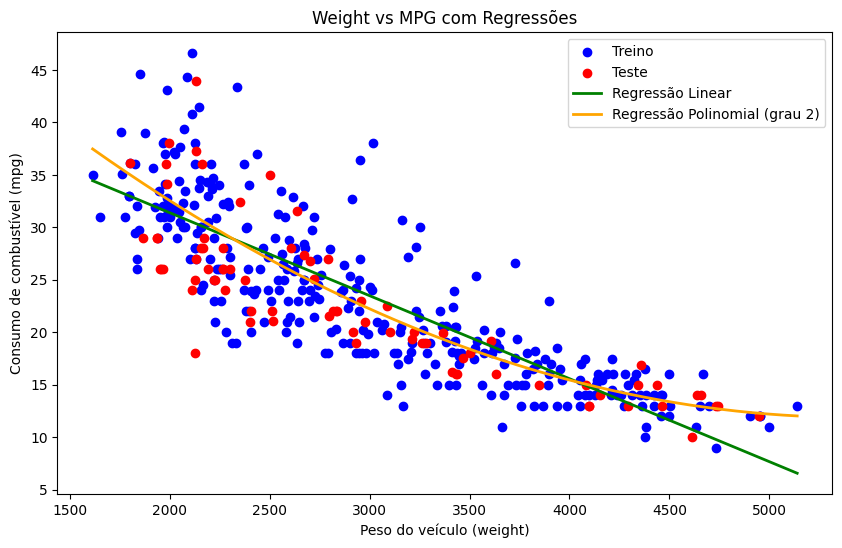

In [24]:
import numpy as np
import pandas as pd

x_range = pd.DataFrame({
    "weight": np.linspace(X_weight["weight"].min(), ## Utilizado IA para ajustar o formato do DataFrame e evitar warnings do Scikit-Learn
                          X_weight["weight"].max(),
                          500)
})


y_linear_curve = modelo_linear.predict(x_range)
y_poly_curve = modelo_polinomial.predict(x_range)

plt.figure(figsize=(10,6))

plt.scatter(X_train, y_train, color="blue", label="Treino")
plt.scatter(X_test, y_test, color="red", label="Teste")


plt.plot(x_range, y_linear_curve, color="green", linewidth=2, label="Regressão Linear")

plt.plot(x_range, y_poly_curve, color="orange", linewidth=2, label="Regressão Polinomial (grau 2)")


plt.title("Weight vs MPG com Regressões")
plt.xlabel("Peso do veículo (weight)")
plt.ylabel("Consumo de combustível (mpg)")
plt.legend()
plt.show()

### <font color='cyan'>Q13) Com base no gráfico gerado, qual modelo parece se ajustar melhor aos dados? A relação entre `weight` e `mpg` parece ser linear ou não linear? Explique.</font>

O modelo de regressão polinomial parece se ajustar melhor aos dados, pois acompanha de maneira mais próxima a curvatura observada na distribuição dos pontos. A relação parece ser não linear pois o comportamento apresenta uma leve curva nas regiões de veículos mais leves.

### <font color='cyan'>Q14) Os resultados observados no gráfico são consistentes com a análise das métricas? Explique possíveis diferenças entre a avaliação quantitativa (métricas) e a avaliação visual do ajuste dos modelos.</font>

Sim, os resultados observados são consistentes com as métricas obtidas. O modelo polinomial apresenta maior R² e menores erros (MAE e MSE), o que confirma o melhor ajuste da curva aos dados.

### <font color='cyan'>Q15) Para observar o efeito do sobreajuste (overfitting) na prática, treine um novo modelo de Regressão Polinomial, mas desta vez utilizando um grau bem alto (por exemplo, grau 15 ou 20). Utilize o mesmo processo com o Pipeline (incluindo o escalonamento). Imprima as métricas de treinamento e teste. O que acontece com o desempenho no conjunto de teste em comparação ao de treinamento? Explique o fenômeno ocorrido.</font>

In [25]:
modelo_overfit = Pipeline([
    ("poly", PolynomialFeatures(degree=15)),
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])


modelo_overfit.fit(X_train, y_train)


y_train_overfit = modelo_overfit.predict(X_train)
y_test_overfit = modelo_overfit.predict(X_test)


print("TREINAMENTO:")
print("R²:", r2_score(y_train, y_train_overfit))
print("MAE:", mean_absolute_error(y_train, y_train_overfit))
print("MSE:", mean_squared_error(y_train, y_train_overfit))


print("TESTE:")
print("R²:", r2_score(y_test, y_test_overfit))
print("MAE:", mean_absolute_error(y_test, y_test_overfit))
print("MSE:", mean_squared_error(y_test, y_test_overfit))

TREINAMENTO:
R²: 0.7327703085197614
MAE: 3.038874336983417
MSE: 16.86212512177661
TESTE:
R²: 0.6607155225334981
MAE: 3.1583075349946808
MSE: 17.31727761412323


O modelo apresenta desempenho muito melhor no conjunto de treinamento do que no conjunto de teste. Ocorre porque o modelo de grau muito alto acaba memorizando os dados de treino, incluindo ruídos e variações específicas. Ocorre o overfitting, no qual o modelo perde capacidade de generalização para novos dados.


## <font color='green'>**3. Otimização com Gradiente Descendente**</font>

### <font color='cyan'>Q16) Tente treinar um `SGDRegressor` diretamente nos dados originais de `X` (removendo valores nulos se houver) e observe o erro.</font>

In [26]:
from sklearn.linear_model import SGDRegressor

dados = X.copy()
dados["mpg"] = y

dados = dados.dropna()

X_sgd = dados.drop(columns=["mpg"])
y_sgd = dados["mpg"]

sgd_model = SGDRegressor(random_state=42)

sgd_model.fit(X_sgd, y_sgd)

print("R²:", sgd_model.score(X_sgd, y_sgd))

R²: -7.811349202383778e+29


### <font color='cyan'>Q17) Agora, aplique o `StandardScaler` do Scikit-Learn nos dados e treine o `SGDRegressor` novamente.</font>

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


sgd_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("sgd", SGDRegressor(random_state=42))
])


sgd_pipeline.fit(X_sgd, y_sgd)


print("R²:", sgd_pipeline.score(X_sgd, y_sgd))

R²: 0.8198182447352234


### <font color='cyan'>Q18) Compare os resultados das duas abordagens e explique por que a normalização é importante para algoritmos baseados em gradiente descendente. Relacione sua resposta com o comportamento do gradiente e a escala das variáveis.</font>

A normalização é importante pois sem ela, variáveis com valores muito grandes dominam o cálculo do gradiente, fazendo com que o algoritmo tenha dificuldade para encontrar o mínimo da função de custo. Ao aplicar o StandardScaler, todas as variáveis passam a ter média próxima de 0 e desvio padrão próximo de 1. Assim, o gradiente consegue atualizar os coeficientes de maneira mais equilibrada, tornando o treinamento mais eficiente e estável.

## <font color='green'>**4. Validação Cruzada e Regularização (LASSO)**</font>

### <font color='green'>A Regressão LASSO (Least Absolute Shrinkage and Selection Operator) é uma evolução da Regressão Linear tradicional. Na regressão comum, o modelo foca apenas em reduzir o erro. O problema é que, ao tentar usar todas as variáveis disponíveis, ele pode acabar decorando ruídos e gerando overfitting. O LASSO resolve isso adicionando uma penalidade aos coeficientes (pesos) das variáveis.</font>
- #### <font color='green'>O grande diferencial da regularização do LASSO (chamada de L1) é que ela consegue forçar os coeficientes de variáveis inúteis ou redundantes a se tornarem exatamente zero. Ou seja, o próprio modelo decide quais dados ignorar, entregando uma equação final mais simples, limpa e interpretável.</font>
- #### <font color='green'>O hiperparâmetro `alpha` é o "botão de volume" da penalidade. Se alpha = 0, temos uma regressão linear normal. Quanto maior o valor de alpha, mais severa é a penalização e mais atributos o modelo irá descartar.</font>

### <font color='green'>Caso queira entender a matemática por trás da função de custo, consulte os seguintes materiais:</font>
- #### <font color='green'>Anexo III do [material  teórico](https://github.com/zz4fap/c24_inteligencia_artificial/blob/main/slides/C24_Regress%C3%A3o.pdf) da disciplina  (slides 96 em diante);</font>
- #### <font color='green'>Documentação oficial do Scikit-Learn sobre [modelos lineares com LASSO](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html);</font>
- #### <font color='green'>Vídeo ["Regularization Part 2: Lasso (L1) Regression"](https://www.youtube.com/watch?v=NGf0voTMlcs), do canal "StatQuest with Josh Starmer", com uma explicação didática e visual sobre como a matemática do LASSO zera os coeficientes.</font>

### <font color='cyan'>Q19) O algoritmo LASSO é extremamente sensível à escala dos dados, pois ele penaliza a magnitude bruta dos coeficientes. Crie um `Pipeline` que aplique o `StandardScaler` e, em seguida, o modelo `Lasso(alpha=1.0)`. Treine-o com todos os dados (`X` e `y`) e exiba os coeficientes finais. A aplicação da normalização mudou a relevância que o modelo deu às variáveis em comparação com a Q16 (onde não usamos normalização)? Explique.</font>

In [28]:
from sklearn.linear_model import Lasso


lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=1.0))
])


lasso_pipeline.fit(X_sgd, y_sgd)


coeficientes = lasso_pipeline.named_steps["lasso"].coef_


for nome, coef in zip(X_sgd.columns, coeficientes):
    print(f"{nome}: {coef}")

displacement: -0.0
cylinders: -0.0
horsepower: -0.16769978871104282
weight: -4.545531522260866
acceleration: 0.0
model_year: 1.9944362824006048
origin: 0.3082902195174502


A normalização altera a importância atribuída às variáveis pelo modelo LASSO. Isso ocorre porque o LASSO penaliza diretamente os coeficientes. Sem normalização, variáveis com escalas maiores tendem a dominar o modelo. Após aplicar o StandardScaler, todas as variáveis passam a competir em igualdade de escala, permitindo que o LASSO selecione atributos de forma mais justa e interprete melhor quais variáveis realmente são relevantes.

### <font color='cyan'>Q20) O hiperparâmetro alpha é quem dita a força da regularização. Utilizando o mesmo processo com o Pipeline e o StandardScaler, treine três modelos LASSO distintos, alterando o valor de alpha para: 0.1, 1.0 e 5.0. Imprima apenas os nomes das variáveis que "sobreviveram" (ou seja, que tiveram coeficientes diferentes de zero) em cada modelo. O que acontece com a complexidade do modelo à medida que o valor de alpha aumenta?</font>

In [30]:
alphas = [0.1, 1.0, 5.0]

for alpha in alphas:

    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=alpha))
    ])

    modelo.fit(X_sgd, y_sgd)

    coeficientes = modelo.named_steps["lasso"].coef_

    variaveis_ativas = [
        nome
        for nome, coef in zip(X_sgd.columns, coeficientes)
        if coef != 0
    ]

    print(f"\nAlpha = {alpha}")
    print("Variaveis sobreviventes:")
    print(variaveis_ativas)


Alpha = 0.1
Variaveis sobreviventes:
['horsepower', 'weight', 'acceleration', 'model_year', 'origin']

Alpha = 1.0
Variaveis sobreviventes:
['horsepower', 'weight', 'model_year', 'origin']

Alpha = 5.0
Variaveis sobreviventes:
['weight']


À medida que o valor de alpha aumenta mais coeficientes são reduzidos para zero, menos variáveis permanecem no modelo e o modelo se torna mais simples.